In [ ]:
import json
import pandas as pd
import requests
from bs4 import BeautifulSoup
import requests, json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def parse_fifa_ranking_safe():
    url = "https://inside.fifa.com/fifa-world-ranking/men"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    try:
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Erro ao aceder à página: {response.status_code}")
            return None

        soup = BeautifulSoup(response.text, "html.parser")
        script_tag = soup.find("script", id="__NEXT_DATA__")

        if script_tag:
            json_data = json.loads(script_tag.string)

            # Vamos extrair do nó 'boldCards' tratando o erro do int() convertendo primeiro para float
            bold_cards = json_data["props"]["pageProps"]["pageData"]["ranking"][
                "boldCards"
            ]

            dados_equipas = []
            for card in bold_cards:
                # Se não for um ranking numérico puro (ex: variação de pontos '15.75'), ignoramos o erro
                try:
                    raw_val = card["cardValue"]
                    # Converte para float primeiro (resolve o '15.75') e depois para int
                    ranking_num = int(float(raw_val))
                except ValueError:
                    # Se for um texto ou algo inválido para ranking, assume 0 ou ignora
                    continue

                dados_equipas.append(
                    {
                        "Ranking_FIFA": ranking_num,
                        "Equipa": card["countryName"],
                        "Sigla": card["countryCode"],
                    }
                )

            df_ranking = pd.DataFrame(dados_equipas)

            # Remover duplicados e ordenar pelo Ranking real
            df_ranking = df_ranking.drop_duplicates(subset=["Equipa"]).sort_values(
                "Ranking_FIFA"
            )
            return df_ranking
        else:
            print("Tag __NEXT_DATA__ não encontrada.")
            return None

    except Exception as e:
        print(f"Erro no processamento: {e}")
        return None


# Executar
df_fifa = parse_fifa_ranking_safe()

if df_fifa is not None and not df_fifa.empty:
    print("Sucesso! Amostra dos dados do ranking extraídos:")
    print(df_fifa)
else:
    print("Não foi possível gerar dados válidos com este nó do JSON.")

Sucesso! Amostra dos dados do ranking extraídos:
   Ranking_FIFA     Equipa Sigla
0             1  Argentina   ARG
1             4  Indonesia   IDN
3             7    Morocco   MAR
4             7    Lebanon   LBN
2            15      Yemen   YEM


In [ ]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/125.0.0.0 Safari/537.36"
    )
}

URL = "https://inside.fifa.com/fifa-world-ranking/men"

def fetch_next_data(url: str) -> dict:
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")
    tag = soup.find("script", {"id": "__NEXT_DATA__"})
    if not tag:
        raise ValueError("Tag __NEXT_DATA__ não encontrada.")
    return json.loads(tag.string)


def explore_keys(d, depth=0, max_depth=5, path="root"):
    """
    Imprime a estrutura do dict recursivamente.
    Se o valor for uma lista, mostra o comprimento e o tipo do primeiro elemento.
    """
    if depth > max_depth:
        return
    indent = "  " * depth
    if isinstance(d, dict):
        for key, value in d.items():
            current_path = f"{path}.{key}"
            if isinstance(value, dict):
                print(f"{indent}[dict] {key}/")
                explore_keys(value, depth + 1, max_depth, current_path)
            elif isinstance(value, list):
                elem_type = type(value[0]).__name__ if value else "empty"
                print(f"{indent}[list len={len(value)} elem={elem_type}] {key}  →  path: {current_path}")
                # Entra no primeiro elemento se for dict (para ver a estrutura interna)
                if value and isinstance(value[0], dict):
                    explore_keys(value[0], depth + 1, max_depth, f"{current_path}[0]")
            else:
                preview = str(value)[:60]
                print(f"{indent}[{type(value).__name__}] {key} = {preview}")


if __name__ == "__main__":
    data = fetch_next_data(URL)
    page_data = data["props"]["pageProps"]["pageData"]["ranking"]
    print("=== Chaves em 'ranking' ===")
    explore_keys(page_data, max_depth=4)

=== Chaves em 'ranking' ===
[list len=6 elem=dict] confederations  →  path: root.confederations
  [str] value = AFC
  [str] text = AFC
  [str] logo = https://api.fifa.com/api/v3/picture/confederations-sq-2/AFC
[list len=35 elem=dict] dates  →  path: root.dates
  [str] year = 2026
  [list len=3 elem=dict] dates  →  path: root.dates[0].dates
    [str] id = FRS_Male_Football_20260401
    [str] iso = 2026-06-11T10:00:59.636Z
    [str] dateText = 11 June
    [str] matchWindowEndDate = 2026-06-11
[list len=347 elem=dict] allAvailableDates  →  path: root.allAvailableDates
  [str] id = FRS_Male_Football_20260401
  [str] date = 2026-06-11
  [str] matchWindowEndDate = 2026-06-11
[NoneType] selectedConfederation = None
[dict] rankingListLabels/
  [str] rankLabel = RK
  [str] rankLabelMobile = Rk.
  [str] teamLabel = Team
  [str] totalPointsLabel = Total Points
  [str] totalPointsLabelMobile = Pts
  [str] previousPointsLabel = Previous Points
  [str] plusMinusLabel = +/-
  [str] plusMinusLabelMobi

In [ ]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",
    "Referer": "https://inside.fifa.com/",
    "Origin":  "https://inside.fifa.com",
}

API_URL = "https://api.fifa.com/api/v3/fifarankings/rankings/live?gender=1&sportType=0&language=en"

r = requests.get(API_URL, headers=HEADERS, timeout=15)
payload = r.json()

# Ver tipo e chaves de topo
print("Tipo:", type(payload))
if isinstance(payload, dict):
    print("Chaves de topo:", list(payload.keys()))
    for k, v in payload.items():
        print(f"  '{k}' → tipo: {type(v).__name__}, ", end="")
        if isinstance(v, list):
            print(f"len={len(v)}")
        elif isinstance(v, dict):
            print(f"chaves: {list(v.keys())}")
        else:
            print(f"valor: {str(v)[:80]}")
elif isinstance(payload, list):
    print(f"Lista com {len(payload)} elementos")
    print("Primeiro elemento:", json.dumps(payload[0], indent=2))

Tipo: <class 'dict'>
Chaves de topo: ['ContinuationToken', 'ContinuationHash', 'Results']
  'ContinuationToken' → tipo: NoneType, valor: None
  'ContinuationHash' → tipo: NoneType, valor: None
  'Results' → tipo: list, len=211


In [ ]:

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",
    "Referer": "https://inside.fifa.com/",
    "Origin":  "https://inside.fifa.com",
}

API_URL = "https://api.fifa.com/api/v3/fifarankings/rankings/live?gender=1&sportType=0&language=en"


def fetch_fifa_ranking() -> pd.DataFrame:
    response = requests.get(API_URL, headers=HEADERS, timeout=15)
    response.raise_for_status()
    entries = response.json()["Results"]

    records = []
    for entry in entries:
        records.append({
            "ranking":      entry.get("rankingPosition") or entry.get("rank"),
            "country_name": entry.get("teamName")        or entry.get("name"),
            "country_code": entry.get("id")              or entry.get("teamId"),
            "points":       entry.get("totalPoints")     or entry.get("points"),
            "confederation": entry["ConfederationName"],  
        })

    return (
        pd.DataFrame(records)
        .sort_values("ranking")
        .reset_index(drop=True)
    )


if __name__ == "__main__":
    df_ranking = fetch_fifa_ranking()
    print(df_ranking.head(10))
    print(f"\nTotal de seleções: {len(df_ranking)}")
    df_ranking.to_csv("fifa_ranking.csv", index=False)
    print("Guardado em 'fifa_ranking.csv'")

  ranking country_name country_code points confederation
0    None         None         None   None      CONMEBOL
1    None         None         None   None          UEFA
2    None         None         None   None          UEFA
3    None         None         None   None          UEFA
4    None         None         None   None      CONMEBOL
5    None         None         None   None           CAF
6    None         None         None   None          UEFA
7    None         None         None   None          UEFA
8    None         None         None   None          UEFA
9    None         None         None   None          UEFA

Total de seleções: 211
Guardado em 'fifa_ranking.csv'


In [ ]:
r = requests.get(API_URL, headers=HEADERS, timeout=15)
print(json.dumps(r.json()["Results"][0], indent=2))

{
  "IdTeam": "43922",
  "TeamName": [
    {
      "Locale": "en-GB",
      "Description": "Argentina"
    }
  ],
  "Gender": 1,
  "IdConfederation": "23915",
  "RankingMovement": 0,
  "ConfederationName": "CONMEBOL",
  "IdCountry": "ARG",
  "RatedMatches": 62,
  "Rank": 1,
  "PrevRank": 1,
  "TotalPoints": 1901.927921,
  "PrevPoints": 1877.266571,
  "RankingStatus": 0,
  "Properties": null,
  "IsUpdateable": null
}


In [ ]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",
    "Referer": "https://inside.fifa.com/",
    "Origin":  "https://inside.fifa.com",
}

API_URL = "https://api.fifa.com/api/v3/fifarankings/rankings/live?gender=1&sportType=0&language=en"


def fetch_fifa_ranking() -> pd.DataFrame:
    response = requests.get(API_URL, headers=HEADERS, timeout=15)
    response.raise_for_status()
    entries = response.json()["Results"]

    records = []
    for entry in entries:
        records.append({
            "ranking":      entry["Rank"],
            "country_name": entry["TeamName"][0]["Description"],  # lista com locale
            "country_code": entry["IdCountry"],                   # ex: "ARG", "POR"
            "points":       entry["TotalPoints"],
            "confederation": entry["ConfederationName"],
        })

    return (
        pd.DataFrame(records)
        .sort_values("ranking")
        .reset_index(drop=True)
    )


if __name__ == "__main__":
    df_ranking = fetch_fifa_ranking()
    print(df_ranking.head(100))
    print(f"\nTotal de seleções: {len(df_ranking)}")
    df_ranking.to_csv("../data/fifa_ranking.csv", index=False)
    print("Guardado em 'fifa_ranking.csv'")

    ranking country_name country_code       points confederation
0         1    Argentina          ARG  1901.927921      CONMEBOL
1         2       France          FRA  1894.400161          UEFA
2         3        Spain          ESP  1864.323084          UEFA
3         4      England          ENG  1847.677458          UEFA
4         5       Brazil          BRA  1772.008748      CONMEBOL
..      ...          ...          ...          ...           ...
95       96      Belarus          BLR  1242.876029          UEFA
96       97    Guatemala          GUA  1238.743750      CONCACAF
97       98   Luxembourg          LUX  1232.818150          UEFA
98       99      Vietnam          VIE  1225.679430           AFC
99      100  El Salvador          SLV  1225.344607      CONCACAF

[100 rows x 5 columns]

Total de seleções: 211
Guardado em 'fifa_ranking.csv'


In [ ]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",
    "Referer": "https://inside.fifa.com/",
    "Origin":  "https://inside.fifa.com",
}

API_URL = "https://api.fifa.com/api/v3/fifarankings/rankings/live?gender=1&sportType=0&language=en"

r = requests.get(API_URL, headers=HEADERS, timeout=15)
entry = r.json()["Results"][0]
print(entry)

{'IdTeam': '43922', 'TeamName': [{'Locale': 'en-GB', 'Description': 'Argentina'}], 'Gender': 1, 'IdConfederation': '23915', 'RankingMovement': 0, 'ConfederationName': 'CONMEBOL', 'IdCountry': 'ARG', 'RatedMatches': 62, 'Rank': 1, 'PrevRank': 1, 'TotalPoints': 1901.927921, 'PrevPoints': 1877.266571, 'RankingStatus': 0, 'Properties': None, 'IsUpdateable': None}


In [ ]:

# --- 1. Estatísticas descritivas ---
print("=== DESCRIBE ===")
print(df_ranking[["ranking", "points"]].describe().round(2))


=== DESCRIBE ===
       ranking   points
count   211.00   211.00
mean    106.00  1229.98
std      61.05   278.78
min       1.00   721.20
25%      53.50  1009.58
50%     106.00  1192.16
75%     158.50  1450.03
max     211.00  1901.93


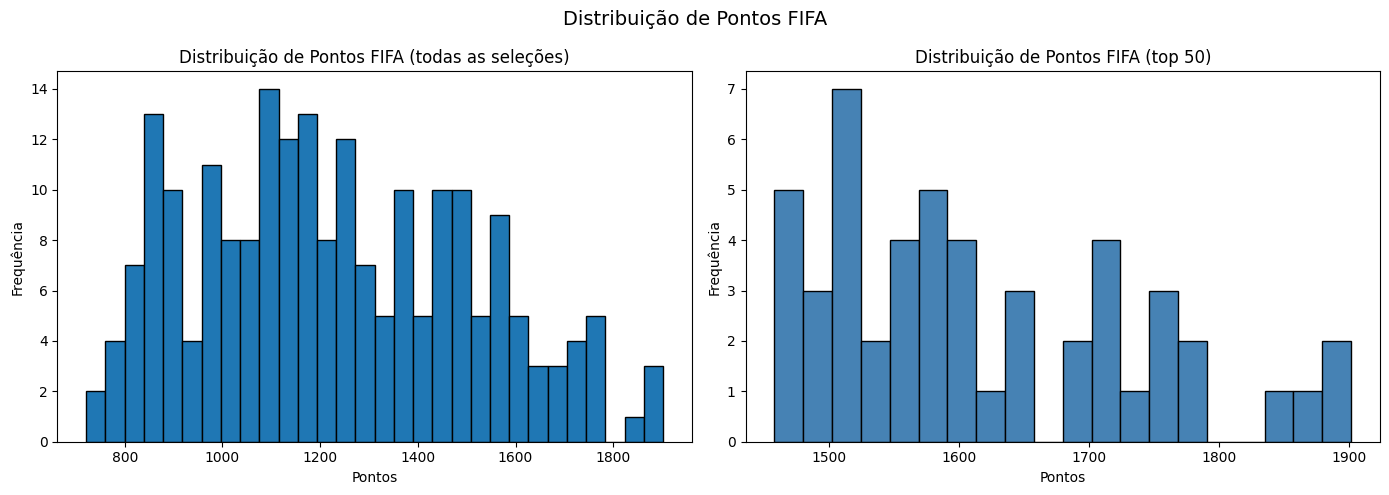

In [10]:
# --- 2. Histograma de pontos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_ranking["points"], bins=30, edgecolor="black")
axes[0].set_title("Distribuição de Pontos FIFA (todas as seleções)")
axes[0].set_xlabel("Pontos")
axes[0].set_ylabel("Frequência")

# Zoom no top 50
axes[1].hist(df_ranking[df_ranking["ranking"] <= 50]["points"], bins=20, edgecolor="black", color="steelblue")
axes[1].set_title("Distribuição de Pontos FIFA (top 50)")
axes[1].set_xlabel("Pontos")
axes[1].set_ylabel("Frequência")

plt.suptitle("Distribuição de Pontos FIFA", fontsize=14)
plt.tight_layout()
plt.show()


distribuição aproximadamente simétrica com ligeiro achatamento nas caudas

Massa concentrada entre 900-1600 pontos — o "pelotão do meio"

Top 50 mostra distribuição bimodal (~1500 e ~1700) — há dois clusters de qualidade mesmo no topo

 a FIFA tem um sistema de pontuação que tende a comprimir as equipas para o meio — as diferenças entre equipas medianas são pequenas, e só os extremos (top 5 e bottom 10) se destacam.


=== ANÁLISE POR CONFEDERAÇÃO ===
               n_equipas  ranking_medio  pontos_medio  melhor_ranking  pior_ranking
confederation                                                                      
CONMEBOL              10           32.7        1582.3               1            77
UEFA                  55           71.0        1391.5               2           211
CAF                   54          108.7        1208.8               6           204
AFC                   46          124.7        1142.3              16           203
CONCACAF              35          135.4        1100.7              11           210
OFC                   11          163.0         984.4              84           200


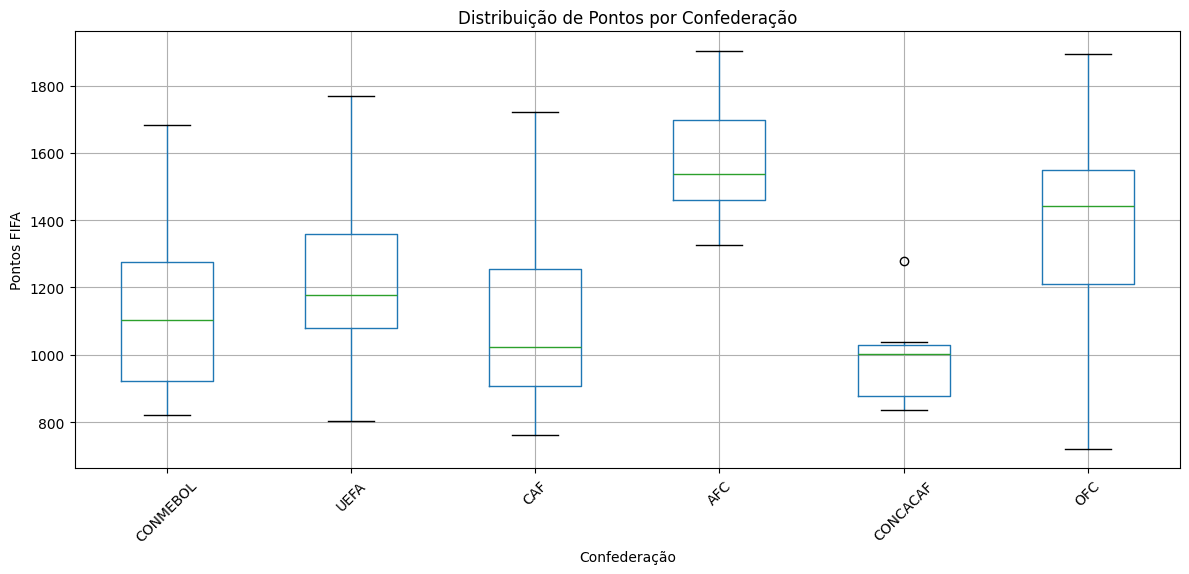


=== TOP 50 POR CONFEDERAÇÃO ===
confederation
UEFA        25
CONMEBOL     9
CAF          8
CONCACAF     4
AFC          4
Name: count, dtype: int64


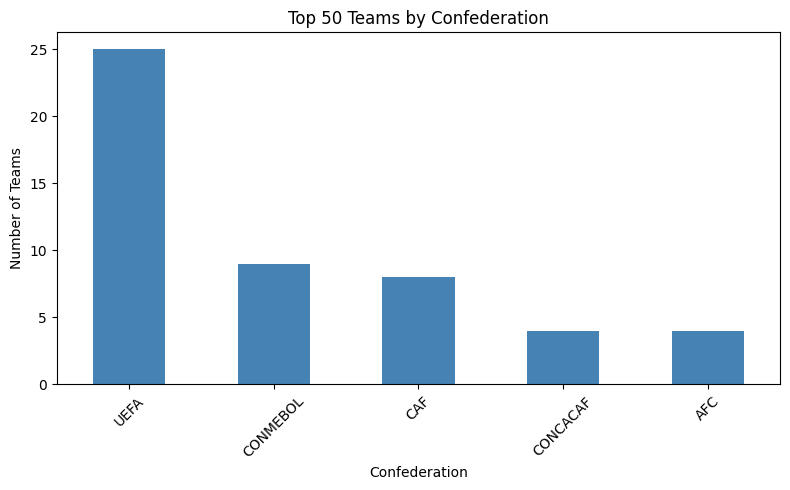

In [ ]:
# --- 3. Análise por confederação ---
conf_stats = df_ranking.groupby("confederation").agg(
    n_equipas=("ranking", "count"),
    ranking_medio=("ranking", "mean"),
    pontos_medio=("points", "mean"),
    melhor_ranking=("ranking", "min"),
    pior_ranking=("ranking", "max"),
).round(1).sort_values("ranking_medio")

print("\n=== ANÁLISE POR CONFEDERAÇÃO ===")
print(conf_stats.to_string())

# --- 4. Boxplot pontos por confederação ---
fig, ax = plt.subplots(figsize=(12, 6))
order = conf_stats.index.tolist()
df_ranking.boxplot(column="points", by="confederation", ax=ax,
                   positions=range(len(order)))
ax.set_xticklabels(order, rotation=45)
ax.set_title("Distribuição de Pontos por Confederação")
ax.set_xlabel("Confederação")
ax.set_ylabel("Pontos FIFA")
plt.suptitle("")
plt.tight_layout()
plt.show()

# --- 5. Top 50 por confederação ---
top50 = df_ranking[df_ranking["ranking"] <= 50]
print("\n=== TOP 50 POR CONFEDERAÇÃO ===")
print(top50["confederation"].value_counts())

# Filter top 50
top50 = df_ranking[df_ranking["ranking"] <= 50]

# Count confederations
conf_counts = top50["confederation"].value_counts()

# Plot
plt.figure(figsize=(8, 5))
conf_counts.plot(kind="bar", color="steelblue")

plt.title("Top 50 Teams by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Number of Teams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


A AFC com ranking médio 124.7 mas pontos médios 1142 é enganadora — tem outliers fortes (Japão #16, Coreia do Sul #23, Irão #22) que distorcem a média. O boxplot confirma: IQR enorme na AFC.

A CONMEBOL é a confederação mais forte em termos de pontos médios (1582) com apenas 10 equipas — densidade de qualidade brutal. Justifica Argentina e Brasil como favoritos.

A UEFA tem 25 das top 50 mas ranking médio 71 — muitas equipas medianas arrastam a média para baixo.

In [15]:
# --- 6. Cliff de pontos — diferença entre posições consecutivas ---
df_ranking["diff_pontos"] = df_ranking["points"].diff(-1).round(2)
print("\n=== MAIORES CLIFFS DE PONTOS ===")
print(df_ranking.nlargest(10, "diff_pontos")[
    ["ranking", "country_name", "points", "diff_pontos"]
].to_string(index=False))


=== MAIORES CLIFFS DE PONTOS ===
 ranking country_name      points  diff_pontos
       4      England 1847.677458        75.67
     210     Anguilla  760.251852        39.05
       2       France 1894.400161        30.08
       9     Portugal 1755.093610        27.22
      16        Japan 1681.262054        26.32
     171  Afghanistan  968.073401        21.64
      63   Cabo Verde 1401.770667        20.59
     173     Maldives  943.917901        20.14
      33      Ukraine 1549.287173        19.68
      19      Senegal 1638.361429        18.89


O maior cliff é entre Inglaterra (#4) e Brasil (#5) — 75 pontos. Isto significa que no Diff_Ranking a diferença de 1 posição entre #4 e #5 vale muito mais do que entre #50 e #51. O Diff_Ranking trata todas as posições como iguais — é uma limitação real do modelo.

Isto abre uma melhoria concreta: usar Diff_Points (diferença de pontos FIFA) em vez de Diff_Ranking (diferença de posições). Reflectiria melhor a distância real entre equipas.